In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Flatten, Dense, Concatenate
from tensorflow.keras.preprocessing.image import load_img, img_to_array

2025-04-22 20:10:50.336497: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-22 20:10:50.344372: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-22 20:10:50.371733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745352650.417526   11488 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745352650.430418   11488 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745352650.461969   11488 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
# 1. Load
df = pd.read_csv('youtube_cleaned_success_only.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11731 entries, 0 to 11730
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       11731 non-null  object
 1   title          11731 non-null  object
 2   channel        11731 non-null  object
 3   channel_id     11731 non-null  object
 4   published      11731 non-null  object
 5   views          11731 non-null  int64 
 6   likes          11731 non-null  int64 
 7   thumbnail_url  11731 non-null  object
 8   category_id    11731 non-null  int64 
 9   subscribers    11731 non-null  int64 
 10  region         11731 non-null  object
 11  Source.Name    1823 non-null   object
dtypes: int64(4), object(8)
memory usage: 1.1+ MB


In [4]:
df['published']    = pd.to_datetime(df['published'],
                                    format="%Y-%m-%dT%H:%M:%SZ",
                                    errors='coerce')
df.dropna(subset=['published'], inplace=True)
df.reset_index(drop=True, inplace=True)
df['publish_hour'] = df['published'].dt.hour
df['day_of_week']  = df['published'].dt.day_name()

rads = 2 * np.pi * df['publish_hour'] / 24

# 2) create two features
df['hour_sin'] = np.sin(rads)
df['hour_cos'] = np.cos(rads)

# 3) drop the original
df.drop(columns=['publish_hour'], inplace=True)

df.drop(['Source.Name'], axis=1, inplace=True, errors='ignore')


In [5]:
# 3. Build image tensor
IMG_SIZE = (128, 128)
def load_image(video_id):
    path = f'youtube_thumbnails/{video_id}.jpg'
    try:
        img = load_img(path, target_size=IMG_SIZE)
        return img_to_array(img) / 255.0
    except:
        return np.zeros((*IMG_SIZE, 3))

image_tensor = np.stack(df['video_id'].apply(load_image).values)  # shape = (N,128,128,3)

In [6]:
# 4. Prepare tabular features
tab_df = df.drop(columns=[
    'video_id','views','title','channel','channel_id','thumbnail_url',
    'published'
])
tab_df = pd.get_dummies(
    tab_df,
    columns=['region','day_of_week','category_id'],
    drop_first=True
)
scaler = StandardScaler()
X_tabular = scaler.fit_transform(tab_df)  # shape = (N, D_tab)

In [7]:
# 5. Target
y = np.log1p(df['views'].values)

# 6. Train/validation split
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    image_tensor, X_tabular, y, test_size=0.2, random_state=42
)

In [8]:
# 7. Build a very simple multi‑input model
#    (MODIFIED: Flatten image → Dense instead of Conv2D stack)

# Image branch
img_input = Input(shape=(128,128,3), name='image_input')
x = Flatten()(img_input)
x = Dense(32, activation='relu')(x)           # image embedding

# Tabular branch
tab_input = Input(shape=(X_tabular.shape[1],), name='tabular_input')
t = Dense(32, activation='relu')(tab_input)   # tabular embedding

# Merge & output
combined = Concatenate()([x, t])
z = Dense(16, activation='relu')(combined)
output = Dense(1, activation='linear')(z)     # regression output

# Create & compile
model = Model(inputs=[img_input, tab_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


2025-04-22 20:11:19.605838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │  1,572,896 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        960 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      1,040 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,574,913 (6.01 MB)

 Trainable params: 1,574,913 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_val, X_tab_val], y_val),
    epochs=20,
    batch_size=32
)


Epoch 1/20


2025-04-22 20:11:20.712309: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1558315008 exceeds 10% of free system memory.


248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 51.7351 - mae: 4.7187 - val_loss: 15.0048 - val_mae: 3.0606
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 12.1980 - mae: 2.7189 - val_loss: 9.8608 - val_mae: 2.4607
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 7.5520 - mae: 2.1072 - val_loss: 6.3916 - val_mae: 1.8143
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 5.1101 - mae: 1.7077 - val_loss: 5.2739 - val_mae: 1.6027
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 4.0771 - mae: 1.4883 - val_loss: 6.3473 - val_mae: 1.7570
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.6061 - mae: 1.3828 - val_loss: 4.5571 - val_mae: 1.5020
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 3.1145 - mae: 1.2827 - val_loss: 4.5671 - val_mae: 1.5580
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 3.0000 - mae: 1.2503 - val_loss: 4.1068 - val_mae: 1.4195
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step -

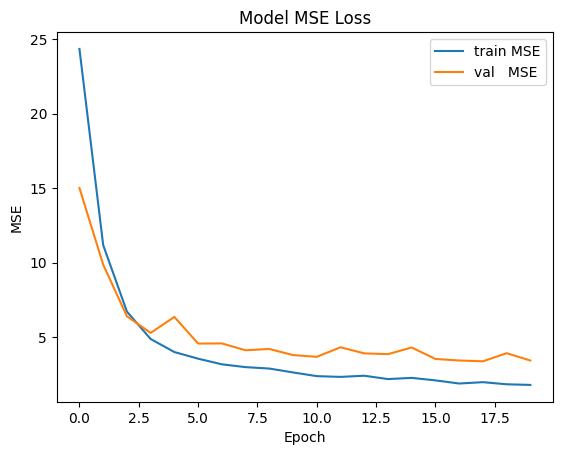

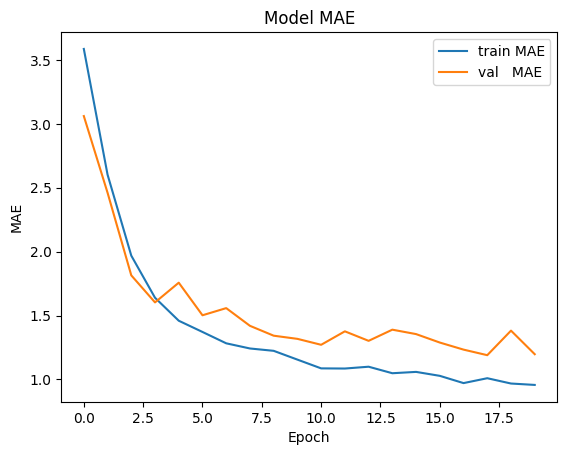

In [10]:
import matplotlib.pyplot as plt

# Loss (MSE) curve
plt.plot(history.history['loss'],    label='train MSE')
plt.plot(history.history['val_loss'],label='val   MSE')
plt.title("Model MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# MAE curve
plt.plot(history.history['mae'],     label='train MAE')
plt.plot(history.history['val_mae'], label='val   MAE')
plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


In [11]:
val_mse, val_mae = model.evaluate(
    [X_img_val, X_tab_val],
    y_val,
    batch_size=32,
    verbose=1
)
print(f"Validation MSE = {val_mse:.2f}")
print(f"Validation MAE = {val_mae:.2f}")


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6521 - mae: 1.2266
Validation MSE = 3.42
Validation MAE = 1.20


In [12]:
from sklearn.metrics import r2_score

y_pred_log = model.predict([X_img_val, X_tab_val]).flatten()
r2_log = r2_score(y_val, y_pred_log)
print(f"R² (log1p) = {r2_log:.3f}")


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
R² (log1p) = 0.638
